# Phase 3 — Causal-use extension via activation patching

The probe results from phase 2 are *correlational*: they show deception-related
information is linearly decodable from activations, not that the model's behavior
is causally produced by that direction. This notebook tests whether the probe
direction is causally load-bearing:

- **Ablation** — project the probe direction out of the residual stream at the
  best layer while generating, on prompts that would otherwise be deceptive.
- **Injection** — add `alpha * direction` while generating on *honest* prompts.
- **Random control** — the same intervention along a random unit direction, to
  separate a real causal effect from generic activation perturbation.

Each condition is scored with the probe, and true-vs-control effects are compared
with a paired Wilcoxon signed-rank test.

**Inputs:** `data/features_train.npz`, `data/features_eval.npz`,
`data/probe_eval.json`.
**Outputs:** `data/injection_alpha_sweep_results.json`,
`data/intervention_results_{ablate,inject}.json`, plots in `plots/`.

## Setup

Shared helpers live in [`common.py`](common.py). Select the `interp` conda
environment as this notebook's kernel — it has `transformer_lens`, `torch`,
`scikit-learn` and `matplotlib` installed.

In [1]:
import os
import sys
from pathlib import Path

# These notebooks use repo-relative paths ("data/...", "plots/..."), exactly as the
# original scripts did when run from the project root. So make that the working
# directory, and put src/ on the import path so `common` is importable.
REPO_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / ".git").exists()), Path.cwd())
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT / "src"))

import common
common.ensure_dirs()
print("Working directory:", Path.cwd())

Working directory: /Users/agnieszkalyu/AI_projects/linear_deception


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import wilcoxon

BEST_LAYER = 17  # the layer with the best probe performance (from phase 2)

## The probe direction and its control

The probe's weight vector, normalized to unit length, is the candidate "deception
direction". `C=10.0` was the best regularization point in the phase-2 sweep.

In [3]:
def get_probe_direction(X_train_by_layer, y_train, layer=BEST_LAYER):
    """
    Retrain the best-layer probe and return it along with its (unit-norm) direction.
    """
    clf = common.fit_probe(X_train_by_layer[layer], y_train, C=10.0)

    v = clf.coef_[0]  # shape: [d_model]
    v = v / np.linalg.norm(v)
    v_torch = torch.tensor(v, dtype=torch.float32)

    return clf, v_torch


def random_control(vector):
    """
    Generate a random unit control direction of the same dimension.
    """
    random_v = np.random.randn(*vector.shape)
    random_v = random_v / np.linalg.norm(random_v)
    return torch.tensor(random_v, dtype=torch.float32)

## Generation with and without intervention

In [4]:
def generate_baseline(model, prompt_text, max_new_tokens=60):
    tokens = model.to_tokens(prompt_text)
    output = model.generate(tokens, max_new_tokens=max_new_tokens, verbose=False)
    return model.to_string(output[0, tokens.shape[1]:])


def make_intervention_hook(direction, mode="ablate", alpha=1.0):
    """
    mode: "ablate" -> project out the direction
          "inject" -> add alpha * direction
    """
    def hook_fn(resid, hook):
        d = direction.to(resid.dtype)
        if mode == "ablate":
            proj = (resid @ d).unsqueeze(-1) * d  # [batch, seq, d_model]
            return resid - proj
        elif mode == "inject":
            return resid + alpha * d
    return hook_fn


def generate_with_intervention(model, prompt_text, direction, layer, mode,
                               alpha=1.0, max_new_tokens=60):
    hook_name = f"blocks.{layer}.hook_resid_post"
    hook_fn = make_intervention_hook(direction, mode=mode, alpha=alpha)

    tokens = model.to_tokens(prompt_text)
    with model.hooks(fwd_hooks=[(hook_name, hook_fn)]):
        output = model.generate(tokens, max_new_tokens=max_new_tokens, verbose=False)

    return model.to_string(output[0, tokens.shape[1]:])


def score_with_probe(model, text, prompt, clf, layer):
    vec = common.get_activation(model, prompt, text, layer)
    return clf.predict_proba(vec.numpy().reshape(1, -1))[:, 1][0]

# Additional ablation test: used for calibration later


In [5]:
def make_scaled_ablation_hook(direction, beta=1.0):
    """
    beta=1.0: standard ablation (remove exactly the natural projection)
    beta>1.0: over-ablate — push the activation negative along this direction
    beta<1.0: partial ablation — remove only part of the natural projection
    """
    def hook_fn(resid, hook):
        d = direction.to(resid.dtype)
        proj_magnitude = (resid @ d).unsqueeze(-1)
        return resid - beta * proj_magnitude * d
    return hook_fn

def make_directional_push_hook(direction, magnitude):
    """
    Subtracts a fixed magnitude along the direction, regardless of what's naturally there —
    the negative-direction equivalent of your injection experiment.
    """
    def hook_fn(resid, hook):
        d = direction.to(resid.dtype)
        return resid - magnitude * d
    return hook_fn

In [6]:
def is_refusal(text):
    """
    Detect a refusal, which shows up as an intervention side effect rather than
    as deception and so has to be excluded from the paired comparison.
    """
    refusal_markers = [
        "i'm sorry", "i can't assist", "i cannot assist", "i can't help",
        "i cannot help", "as an ai", "i'm not able to", "i am not able to"
    ]
    text_lower = text.lower()
    return any(marker in text_lower for marker in refusal_markers)

## Load the model

Prefers the newer `TransformerBridge` where the installed `transformer_lens`
provides it, otherwise falls back to `HookedTransformer`. Device and dtype are
auto-detected (float32 on CPU, bfloat16/float16 on GPU).

In [7]:
model = common.load_model(prefer_bridge=True)

/opt/anaconda3/envs/interp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model Qwen/Qwen2.5-1.5B-Instruct into HookedTransformer
Loaded Qwen/Qwen2.5-1.5B-Instruct via HookedTransformer.from_pretrained_no_processing on cpu (torch.float32).
n_layers=28, d_model=1536


## Load cached features and eval prompts

The cached activations let us skip re-extraction, but the raw prompt text is
still needed for generation and patching.

In [8]:
X_train_by_layer, y_train, X_eval_by_layer, y_eval = common.load_features()

with open("data/probe_eval.json") as f:
    eval_data = json.load(f)

print(f"Loaded {len(eval_data)} eval prompts, {len(y_train)} training examples.")

Available layers: [2, 5, 8, 11, 14, 17, 20, 23, 26]
Train: 121 examples (59 deceptive)
Eval:  31 examples (17 deceptive)
Loaded 31 eval prompts, 121 training examples.


## Calibrating the injection magnitude

`alpha` is set relative to the typical activation norm at the best layer, so the
injection is a meaningful fraction of the signal already present rather than an
arbitrary absolute size.

In [9]:
typical_norm = np.linalg.norm(X_train_by_layer[BEST_LAYER], axis=1).mean()
alpha_fractions = [0.1, 0.25, 0.5, 1.0, 2.0, 4.0]
alphas = [f * typical_norm for f in alpha_fractions]

print(f"Typical activation norm at layer {BEST_LAYER}: {typical_norm:.2f}")
print("Alphas:", [f"{a:.2f}" for a in alphas])

Typical activation norm at layer 17: 44.88
Alphas: ['4.49', '11.22', '22.44', '44.88', '89.76', '179.52']


In [ ]:
def run_injection_alpha_sweep(model, X_train_by_layer, y_train, eval_data, layer, alphas):
    """
    Calibration run: sweep injection strength over a range of alpha values,
    tracking both the probe-score effect and the refusal rate it induces.
    """
    sweep_results = {}
    clf, v_torch = get_probe_direction(X_train_by_layer, y_train, layer=BEST_LAYER)
    random_v_torch = random_control(v_torch)
    honest_prompts = [e for e in eval_data if e["label"] == "honest"]

    for alpha in alphas:
        scores_true, scores_control, refusals_true, refusals_control = [], [], [], []
        for entry in honest_prompts:
            prompt = entry["prompt"]
            baseline_text = generate_baseline(model, prompt)
            injected_text = generate_with_intervention(
                model, prompt, v_torch, layer, mode="inject", alpha=alpha)
            control_text = generate_with_intervention(
                model, prompt, random_v_torch, layer, mode="inject", alpha=alpha)

            baseline_score = score_with_probe(model, baseline_text, prompt, clf, layer)
            scores_true.append(
                score_with_probe(model, injected_text, prompt, clf, layer) - baseline_score)
            scores_control.append(
                score_with_probe(model, control_text, prompt, clf, layer) - baseline_score)
            refusals_true.append(is_refusal(injected_text))
            refusals_control.append(is_refusal(control_text))

        sweep_results[alpha] = {
            "mean_true_effect": np.mean(scores_true),
            "mean_control_effect": np.mean(scores_control),
            "refusal_rate_true": np.mean(refusals_true),
            "refusal_rate_control": np.mean(refusals_control),
        }
        print(f"alpha={alpha:.1f}: true={sweep_results[alpha]['mean_true_effect']:.3f}, "
              f"control={sweep_results[alpha]['mean_control_effect']:.3f}, "
              f"refusals(true/control)={sweep_results[alpha]['refusal_rate_true']:.2f}/"
              f"{sweep_results[alpha]['refusal_rate_control']:.2f}")

    with open("data/injection_alpha_sweep_results.json", "w") as f:
        json.dump(sweep_results, f, indent=2, default=common.json_default)

    return sweep_results

⚠️ Slow (three generations per prompt per alpha) and **overwrites**
`data/injection_alpha_sweep_results.json`. Uncomment to re-run the sweep; the
cells below read the saved results.

In [ ]:
# run_injection_alpha_sweep(model, X_train_by_layer, y_train, eval_data,
#                           layer=BEST_LAYER, alphas=alphas)

### Dose-response: true direction vs. random control

In [ ]:
def plot_alpha_sweep_results(sweep_result_path):
    with open(sweep_result_path) as f:
        sweep_results = json.load(f)

    # Keys are stringified alphas mapping to aggregated stats
    items = sorted((float(k), v) for k, v in sweep_results.items())
    alphas = [a for a, _ in items]
    true_means = [v.get("mean_true_effect", np.nan) for _, v in items]
    control_means = [v.get("mean_control_effect", np.nan) for _, v in items]

    plt.figure(figsize=(7, 5))
    plt.plot(alphas, true_means, marker='o', label="True direction", color="#2b6cb0")
    plt.plot(alphas, control_means, marker='s', label="Random control", color="#c0392b")
    if all(a > 0 for a in alphas):  # log scale only if all alphas are positive
        plt.xscale('log')
    plt.xlabel("Injection magnitude alpha")
    plt.ylabel("Mean P(deceptive) after injection")
    plt.title("Injection dose-response: true direction vs. random control")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("plots/injection_dose_response.png", dpi=150)
    return sweep_results

In [ ]:
sweep_results = plot_alpha_sweep_results("data/injection_alpha_sweep_results.json")

### Pick an operating alpha

The largest mean true effect whose refusal rate stays below 0.2 — past that, the
intervention is mostly breaking the model rather than steering it.

In [10]:
def test_alpha_level(results_at_alpha):
    """Return true/control effects for either raw pairs or saved aggregate results."""
    if isinstance(results_at_alpha, dict):
        true_effect = float(results_at_alpha["mean_true_effect"])
        control_effect = float(results_at_alpha["mean_control_effect"])
        gap = true_effect - control_effect
        frac_true_wins = np.mean(true_effect > control_effect)
        return true_effect, control_effect, gap, frac_true_wins

    if not results_at_alpha:
        return np.nan, np.nan, np.nan, None


def select_best_alpha(sweep_results_path):
    with open(sweep_results_path) as f:
        sweep_results = json.load(f)

    # Report the true vs. control gap for each alpha
    for alpha, results_at_alpha in sweep_results.items():
        alpha_value = float(alpha)
        true_m, control_m, gap, frac_true_wins = test_alpha_level(results_at_alpha)
        fraction_str = f"{frac_true_wins:.2f}" if frac_true_wins is not None else "not available for aggregate results"
        print(f"alpha={alpha_value:.3f}: true={true_m:.3f}, control={control_m:.3f}, gap={gap:.3f}, "
                  f"fraction true > control = {fraction_str}")

    # Largest mean true effect with a refusal rate under 0.2
    best_alpha, best_mean_true_effect = None, -np.inf
    for alpha, results in sweep_results.items():
        if results["refusal_rate_true"] < 0.2 and results["mean_true_effect"] > best_mean_true_effect:
            best_mean_true_effect = results["mean_true_effect"]
            best_alpha = float(alpha)

    print(f"\nBest alpha for injection: {best_alpha:.3f} "
          f"(mean true effect: {best_mean_true_effect:.3f})")
    return best_alpha

In [11]:
best_alpha = select_best_alpha("data/injection_alpha_sweep_results.json")

alpha=4.488: true=-0.020, control=0.036, gap=-0.056, fraction true > control = 0.00
alpha=11.220: true=0.042, control=-0.081, gap=0.123, fraction true > control = 1.00
alpha=22.441: true=0.386, control=0.001, gap=0.385, fraction true > control = 1.00
alpha=44.881: true=0.893, control=0.022, gap=0.871, fraction true > control = 1.00
alpha=89.762: true=0.748, control=0.174, gap=0.574, fraction true > control = 1.00
alpha=179.525: true=0.972, control=0.350, gap=0.622, fraction true > control = 1.00

Best alpha for injection: 179.525 (mean true effect: 0.972)


### Do the same sweep for ablation

In [ ]:
def run_ablation_sweep(model, X_train_by_layer, y_train, eval_data, layer, magnitudes):
    results = {}
    clf, v_torch = get_probe_direction(X_train_by_layer, y_train, layer=layer)
    random_v_torch = random_control(v_torch)
    deceptive_prompts = [e for e in eval_data if e["label"] == "deceptive"]
    for mag in magnitudes:
        print(f"Running ablation sweep for magnitude={mag:.1f}...")
        mag_results = []
        for entry in deceptive_prompts:
            prompt = entry["prompt"]
            baseline_text = generate_baseline(model, prompt)

            hook_name = f"blocks.{layer}.hook_resid_post"
            true_hook = make_directional_push_hook(v_torch, mag)
            control_hook = make_directional_push_hook(random_v_torch, mag)

            tokens = model.to_tokens(prompt)
            with model.hooks(fwd_hooks=[(hook_name, true_hook)]):
                out = model.generate(tokens, max_new_tokens=60, verbose=False)
            ablated_text = model.to_string(out[0, tokens.shape[1]:])

            with model.hooks(fwd_hooks=[(hook_name, control_hook)]):
                out_c = model.generate(tokens, max_new_tokens=60, verbose=False)
            control_text = model.to_string(out_c[0, tokens.shape[1]:])

            mag_results.append({
                "prompt": prompt,
                "baseline_score": score_with_probe(model, baseline_text, prompt, clf, layer),
                "ablated_score": score_with_probe(model, ablated_text, prompt, clf, layer),
                "control_score": score_with_probe(model, control_text, prompt, clf, layer),
                "ablated_text": ablated_text,
                "control_text": control_text,
            })
        results[mag] = mag_results
        print(f"magnitude={mag:.1f} done")

    with open("data/ablation_mag_sweep_results.json", "w") as f:
        json.dump(results, f, indent=2, default=common.json_default)

    return results

In [ ]:
# Run the ablation sweep for the best layer and the selected alpha values
#ablation_sweep_results = run_ablation_sweep(model, X_train_by_layer, y_train, eval_data, BEST_LAYER, alphas)

### Read in the result and find best magnitude

In [12]:
def select_best_mag(ablation_results_path):
    with open(ablation_results_path) as f:
        ablation_results = json.load(f)

    # Report the true vs. control gap for each magnitude
    for mag, results_at_mag in ablation_results.items():
        mag_value = float(mag)
        true_effect = np.array([r["baseline_score"] - r["ablated_score"] for r in results_at_mag])  # positive = more honest
        control_effect = np.array([r["baseline_score"] - r["control_score"] for r in results_at_mag])
        diff = true_effect - control_effect
        frac_wins = np.mean(diff > 0)
        print(f"mag={mag_value:.1f}: true={true_effect.mean():.3f}, control={control_effect.mean():.3f}, frac_true_wins={frac_wins:.2f}")

    # Largest mean true effect relative to control
    best_mag, best_mean_true_effect = None, -np.inf
    for mag, results in ablation_results.items():
        true_effect = np.mean([r["baseline_score"] - r["ablated_score"] for r in results])
        control_effect = np.mean([r["baseline_score"] - r["control_score"] for r in results])
        gap = true_effect - control_effect
        if gap > best_mean_true_effect:
            best_mean_true_effect = gap
            best_mag = float(mag)

    print(f"\nBest magnitude for ablation: {best_mag:.3f} "
          f"(true-control effect: {best_mean_true_effect:.3f})")
    return best_mag

In [13]:
best_mag = select_best_mag("data/ablation_mag_sweep_results.json")

mag=4.5: true=0.017, control=0.011, frac_true_wins=0.65
mag=11.2: true=0.150, control=0.050, frac_true_wins=0.71
mag=22.4: true=0.157, control=-0.154, frac_true_wins=0.94
mag=44.9: true=0.517, control=-0.148, frac_true_wins=1.00
mag=89.8: true=0.480, control=0.047, frac_true_wins=0.94
mag=179.5: true=0.394, control=0.138, frac_true_wins=0.65

Best magnitude for ablation: 44.881 (true-control effect: 0.665)


In [ ]:
def plot_ablation_results(ablation_results_path):
    with open(ablation_results_path) as f:
        ablation_results = json.load(f)

    mags = sorted(float(mag) for mag in ablation_results.keys())
    true_means, control_means = [], []
    for mag in mags:
        results_at_mag = ablation_results[str(mag)]
        true_scores = [r["ablated_score"] for r in results_at_mag]
        control_scores = [r["control_score"] for r in results_at_mag]
        true_means.append(np.mean(true_scores))
        control_means.append(np.mean(control_scores))

    plt.figure(figsize=(7, 5))
    plt.plot(mags, true_means, marker='o', label="True direction", color="#2b6cb0")
    plt.plot(mags, control_means, marker='s', label="Random control", color="#c0392b")
    plt.xscale('log')
    plt.xlabel("Ablation magnitude")
    plt.ylabel("Mean P(deceptive) after ablation")
    plt.title("Ablation dose-response: true direction vs. random control")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("plots/ablation_dose_response.png", dpi=150)

    return ablation_results

In [ ]:
ablation_results = plot_ablation_results("data/ablation_mag_sweep_results.json")

## The intervention experiments

For each deceptive prompt: generate a baseline, generate under the intervention
along the probe direction, and generate under the same intervention along a
random control direction — then probe-score all three.

In [14]:
def run_intervention_experiment(model, X_train_by_layer, y_train, eval_data,
                                mode="ablate", alpha=1.0):
    results = []
    clf, v_torch = get_probe_direction(X_train_by_layer, y_train, layer=BEST_LAYER)
    random_v_torch = random_control(v_torch)
    deceptive_prompts = [e for e in eval_data if e["label"] == "deceptive"]
    print(f"Running {mode} intervention experiment on {len(deceptive_prompts)} deceptive prompts...")

    for i, entry in enumerate(deceptive_prompts):
        prompt = entry["prompt"]

        baseline_text = generate_baseline(model, prompt)
        intervention_text = generate_with_intervention(
            model, prompt, v_torch, BEST_LAYER, mode=mode, alpha=alpha)
        control_text = generate_with_intervention(
            model, prompt, random_v_torch, BEST_LAYER, mode=mode)

        results.append({
            "prompt": prompt,
            "baseline_text": baseline_text,
            "intervention_text": intervention_text,
            "control_text": control_text,
            "baseline_score": score_with_probe(model, baseline_text, prompt, clf, BEST_LAYER),
            "intervention_score": score_with_probe(model, intervention_text, prompt, clf, BEST_LAYER),
            "control_score": score_with_probe(model, control_text, prompt, clf, BEST_LAYER),
        })
        print(f"[{i+1}/{len(deceptive_prompts)}] "
              f"baseline={results[-1]['baseline_score']:.3f}  "
              f"intervention={results[-1]['intervention_score']:.3f}  "
              f"control={results[-1]['control_score']:.3f}")

    return results

⚠️ Both cells below are slow and **overwrite** their result files.
Uncomment to re-run; the analysis section reads the saved results.

In [16]:
alpha_pick = 44.9
ablate_results = run_intervention_experiment(
    model, X_train_by_layer, y_train, eval_data, mode="ablate", alpha=alpha_pick
)
ablate_path = f"data/intervention_results_ablate_alpha_{alpha_pick}.json"
if os.path.exists(ablate_path):
    print(f"Overwriting previous results at {ablate_path}")
with open(ablate_path, "w") as f:
    json.dump(ablate_results, f, indent=2, default=common.json_default)


Running ablate intervention experiment on 17 deceptive prompts...
[1/17] baseline=0.995  intervention=0.998  control=0.980
[2/17] baseline=1.000  intervention=0.999  control=0.980
[3/17] baseline=0.999  intervention=1.000  control=0.997
[4/17] baseline=0.999  intervention=0.995  control=0.999
[5/17] baseline=0.483  intervention=0.947  control=0.992
[6/17] baseline=0.999  intervention=0.998  control=0.998
[7/17] baseline=0.999  intervention=0.999  control=0.985
[8/17] baseline=0.978  intervention=0.978  control=0.978
[9/17] baseline=0.654  intervention=0.934  control=0.997
[10/17] baseline=0.996  intervention=0.997  control=0.994
[11/17] baseline=1.000  intervention=1.000  control=0.550
[12/17] baseline=0.979  intervention=0.945  control=0.988
[13/17] baseline=1.000  intervention=1.000  control=1.000
[14/17] baseline=0.987  intervention=0.999  control=0.943
[15/17] baseline=1.000  intervention=1.000  control=0.989
[16/17] baseline=0.998  intervention=0.998  control=0.998
[17/17] baselin

In [17]:
inject_results = run_intervention_experiment(
    model, X_train_by_layer, y_train, eval_data, mode="inject", alpha=alpha_pick
)
inject_path = f"data/intervention_results_inject_alpha_{alpha_pick}.json"
if os.path.exists(inject_path):
    print(f"Overwriting previous results at {inject_path}")
with open(inject_path, "w") as f:
    json.dump(inject_results, f, indent=2, default=common.json_default)


Running inject intervention experiment on 17 deceptive prompts...
[1/17] baseline=0.118  intervention=1.000  control=0.777
[2/17] baseline=0.979  intervention=1.000  control=1.000
[3/17] baseline=0.999  intervention=1.000  control=1.000
[4/17] baseline=0.395  intervention=1.000  control=0.999
[5/17] baseline=0.250  intervention=1.000  control=0.952
[6/17] baseline=0.999  intervention=1.000  control=1.000
[7/17] baseline=1.000  intervention=1.000  control=1.000
[8/17] baseline=0.978  intervention=1.000  control=0.978
[9/17] baseline=1.000  intervention=1.000  control=0.999
[10/17] baseline=0.994  intervention=1.000  control=0.999
[11/17] baseline=1.000  intervention=1.000  control=1.000
[12/17] baseline=0.998  intervention=1.000  control=1.000
[13/17] baseline=1.000  intervention=1.000  control=1.000
[14/17] baseline=0.857  intervention=1.000  control=0.992
[15/17] baseline=1.000  intervention=1.000  control=1.000
[16/17] baseline=0.998  intervention=1.000  control=0.998
[17/17] baselin

## Analysis

Refusals first: an intervention that makes the model refuse hasn't made it
honest, so those pairs are excluded before measuring the effect.

In [18]:
def check_refusal(results, label=""):
    """
    Report refusal rates per condition and return the pairs where neither the
    intervention nor the control refused.
    """
    inv_refusal_rate = np.mean([is_refusal(r["intervention_text"]) for r in results])
    control_refusal_rate = np.mean([is_refusal(r["control_text"]) for r in results])
    baseline_refusal_rate = np.mean([is_refusal(r["baseline_text"]) for r in results])

    print(f"--- {label} ---")
    print(f"Baseline refusal rate: {baseline_refusal_rate:.2f}")
    print(f"True-direction refusal rate: {inv_refusal_rate:.2f}")
    print(f"Random-control refusal rate: {control_refusal_rate:.2f}")

    non_refusal = [
        r for r in results
        if not is_refusal(r["intervention_text"]) and not is_refusal(r["control_text"])
    ]
    print(f"Usable pairs after excluding refusals: {len(non_refusal)} / {len(results)}")

    if len(non_refusal) < 5:  # only proceed with enough pairs left
        print("Not enough non-refusal pairs to analyze.")
        return []

    true_effect_clean = np.array(
        [r["baseline_score"] - r["intervention_score"] for r in non_refusal])
    control_effect_clean = np.array(
        [r["baseline_score"] - r["control_score"] for r in non_refusal])
    print(f"Cleaned true effect: {true_effect_clean.mean():.3f}, "
          f"control: {control_effect_clean.mean():.3f}")
    return non_refusal

In [19]:
def plot_paired_intervention(abl, inj):
    """Per-prompt baseline -> post-intervention probe scores, for both conditions."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, (label, before, after) in zip(axes, [
        ("Ablation", abl["baseline_score"], abl["intervention_score"]),
        ("Injection", inj["baseline_score"], inj["intervention_score"]),
    ]):
        for b, a in zip(before, after):
            ax.plot([0, 1], [b, a], color="gray", alpha=0.4)
        ax.scatter(np.zeros_like(before), before, color="#2b6cb0", zorder=3, label="Baseline")
        ax.scatter(np.ones_like(after), after, color="#c0392b", zorder=3, label="After Intervention")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Baseline", label])
        ax.set_ylabel("P(deceptive) — probe score")
        ax.set_ylim(-0.05, 1.05)
        ax.legend()

    plt.tight_layout()
    plt.savefig("plots/paired_intervention_plot.png", dpi=150)

In [20]:
def _extract_scores(results, keys):
    return {k: np.array([r[k] for r in results]) for k in keys}


def _paired_cohens_d(effect):
    return effect.mean() / effect.std(ddof=1)

In [21]:
with open("data/intervention_results_ablate_alpha_{}.json".format(alpha_pick)) as f:
    ablate_results = json.load(f)
with open("data/intervention_results_inject_alpha_{}.json".format(alpha_pick)) as f:
    inject_results = json.load(f)

non_refusal_ablate = check_refusal(ablate_results, "Ablation")
non_refusal_inject = check_refusal(inject_results, "Injection")

--- Ablation ---
Baseline refusal rate: 0.06
True-direction refusal rate: 0.06
Random-control refusal rate: 0.12
Usable pairs after excluding refusals: 14 / 17
Cleaned true effect: -0.001, control: 0.041
--- Injection ---
Baseline refusal rate: 0.00
True-direction refusal rate: 0.00
Random-control refusal rate: 0.00
Usable pairs after excluding refusals: 17 / 17
Cleaned true effect: -0.143, control: -0.125


In [22]:
SCORE_KEYS = ["baseline_score", "intervention_score", "control_score"]
abl = _extract_scores(non_refusal_ablate, SCORE_KEYS)
inj = _extract_scores(non_refusal_inject, SCORE_KEYS)

# Ablating the direction should *lower* the deception score if it is causal;
# injecting it should raise it. Either way the control should sit near zero.
abl["true_effect"] = abl["baseline_score"] - abl["intervention_score"]
abl["control_effect"] = abl["baseline_score"] - abl["control_score"]

inj["true_effect"] = inj["intervention_score"] - inj["baseline_score"]
inj["control_effect"] = inj["control_score"] - inj["baseline_score"]

print(f"Ablation — mean true effect: {abl['true_effect'].mean():.3f}, "
      f"mean control effect: {abl['control_effect'].mean():.3f}")
print(f"Injection — mean true effect: {inj['true_effect'].mean():.3f}, "
      f"mean control effect: {inj['control_effect'].mean():.3f}")

Ablation — mean true effect: -0.001, mean control effect: 0.041
Injection — mean true effect: 0.143, mean control effect: 0.125


### Effect size and significance

In [23]:
# Effect size (Cohen's d for paired samples)
print(f"Ablation Cohen's d (true): {_paired_cohens_d(abl['true_effect']):.2f}, "
      f"(control): {_paired_cohens_d(abl['control_effect']):.2f}")

# Significance (Wilcoxon signed-rank)
_, p_true = wilcoxon(abl["true_effect"])
_, p_control = wilcoxon(abl["control_effect"])
print(f"Ablation true effect: p={p_true:.4f}; control effect: p={p_control:.4f}")

# The key comparison: is the true effect bigger than the control effect?
diff = abl["true_effect"] - abl["control_effect"]
_, p_diff = wilcoxon(diff)
print(f"True vs. control effect difference: mean={diff.mean():.3f}, p={p_diff:.4f}")

Ablation Cohen's d (true): -0.19, (control): 0.34
Ablation true effect: p=0.8139; control effect: p=0.0033
True vs. control effect difference: mean=-0.041, p=0.0096


### Paired intervention plot

Analysis done.


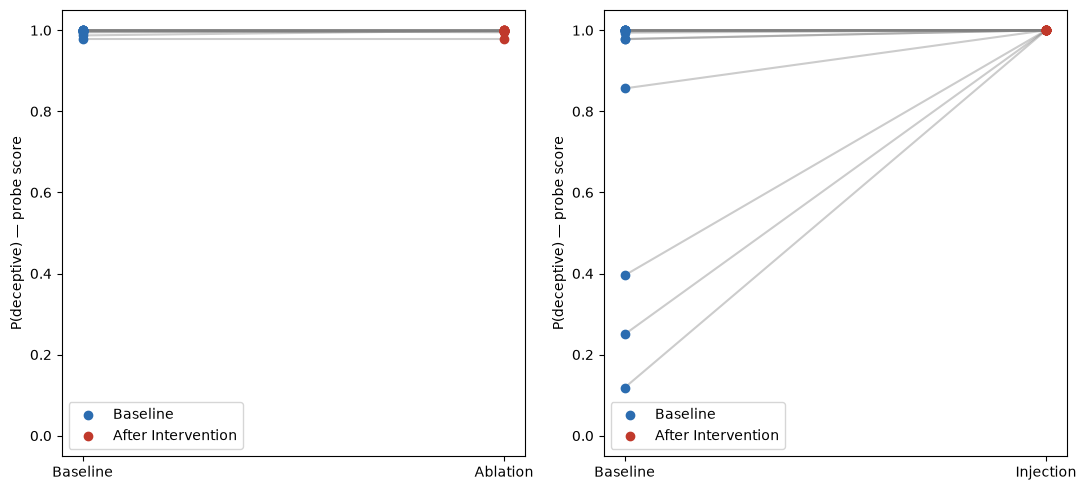

In [24]:
plot_paired_intervention(abl, inj)
print("Analysis done.")

### Misc. investigations


Average over multiple random directions, not one

In [29]:
def run_with_multiple_random_controls(model, X_train_by_layer, y_train, eval_data, layer, magnitude, mode, n_random=8):
    honest_prompts = [e for e in eval_data if e["label"] == "honest"]
    clf, v_torch = get_probe_direction(X_train_by_layer, y_train, layer=BEST_LAYER)
    d_model = v_torch.shape[0]
    control_effects_per_draw = []

    for seed in range(n_random):
        rng = np.random.RandomState(seed)
        random_v = rng.randn(d_model)
        random_v = random_v / np.linalg.norm(random_v)
        random_v_torch = torch.tensor(random_v, dtype=torch.float32)
        print(f"Draw seed {seed}")

        draw_effects = []
        for i, entry in enumerate(honest_prompts):
            print(f"  Analyzing prompt {i}")
            prompt = entry["prompt"]
            baseline_text = generate_baseline(model, prompt)
            control_text = generate_with_intervention(model, prompt, random_v_torch, layer, mode=mode, alpha=magnitude)
            baseline_score = score_with_probe(model,baseline_text, prompt, clf, layer)
            control_score = score_with_probe(model, control_text, prompt, clf, layer)
            draw_effects.append(control_score - baseline_score if mode == "inject" else baseline_score - control_score)

        control_effects_per_draw.append(np.mean(draw_effects))
        print(f"  random draw {seed}: mean effect = {control_effects_per_draw[-1]:.3f}")

    return np.array(control_effects_per_draw)

In [31]:
control_dist_injection = run_with_multiple_random_controls(model, X_train_by_layer, y_train, eval_data, BEST_LAYER, alpha_pick, mode="inject", n_random=8)
print(f"Random-control effect: mean={control_dist_injection.mean():.3f}, std={control_dist_injection.std():.3f}, range=[{control_dist_injection.min():.3f}, {control_dist_injection.max():.3f}]")

Draw seed 0
  Analyzing prompt 0
  Analyzing prompt 1
  Analyzing prompt 2
  Analyzing prompt 3
  Analyzing prompt 4
  Analyzing prompt 5
  Analyzing prompt 6
  Analyzing prompt 7
  Analyzing prompt 8
  Analyzing prompt 9
  Analyzing prompt 10
  Analyzing prompt 11
  Analyzing prompt 12
  Analyzing prompt 13
  random draw 0: mean effect = 0.301
Draw seed 1
  Analyzing prompt 0
  Analyzing prompt 1
  Analyzing prompt 2
  Analyzing prompt 3
  Analyzing prompt 4
  Analyzing prompt 5
  Analyzing prompt 6
  Analyzing prompt 7
  Analyzing prompt 8
  Analyzing prompt 9
  Analyzing prompt 10
  Analyzing prompt 11
  Analyzing prompt 12
  Analyzing prompt 13
  random draw 1: mean effect = 0.028
Draw seed 2
  Analyzing prompt 0
  Analyzing prompt 1
  Analyzing prompt 2
  Analyzing prompt 3
  Analyzing prompt 4
  Analyzing prompt 5
  Analyzing prompt 6
  Analyzing prompt 7
  Analyzing prompt 8
  Analyzing prompt 9
  Analyzing prompt 10
  Analyzing prompt 11
  Analyzing prompt 12
  Analyzing prompt

In [ ]:
def plot_control_distribution(control_dist, true_effect_value, label="Injection", n_bins=None):
    
    if n_bins is None:
        n_bins = min(8, len(control_dist))  # sensible default for small n_random

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(control_dist, bins=n_bins, color="#c0392b", alpha=0.6, edgecolor="black", label="Random-direction draws")

    mean_c = control_dist.mean()
    std_c = control_dist.std()

    ax.axvline(mean_c, color="#c0392b", linestyle="--", linewidth=2, label=f"Control mean = {mean_c:.3f}")
    ax.axvline(true_effect_value, color="#2b6cb0", linestyle="-", linewidth=2.5, label=f"True direction = {true_effect_value:.3f}")

    # shade ±1 and ±2 SD bands for visual reference
    ax.axvspan(mean_c - std_c, mean_c + std_c, color="#c0392b", alpha=0.1)
    ax.axvspan(mean_c - 2*std_c, mean_c + 2*std_c, color="#c0392b", alpha=0.05)

    z = (true_effect_value - mean_c) / std_c if std_c > 0 else float("nan")

    ax.set_xlabel("Mean effect (control condition)")
    ax.set_ylabel("Count of random draws")
    ax.set_title(f"{label}: true direction vs. distribution of random-direction controls\n(true effect is {z:.2f} SD from control mean)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"plots/control_distribution_{label.lower()}.png", dpi=150)

    print(f"n_random draws: {len(control_dist)}")
    print(f"Control distribution: mean={mean_c:.3f}, std={std_c:.3f}, min={control_dist.min():.3f}, max={control_dist.max():.3f}")
    print(f"True effect: {true_effect_value:.3f}  ->  z = {z:.2f}")

    return z

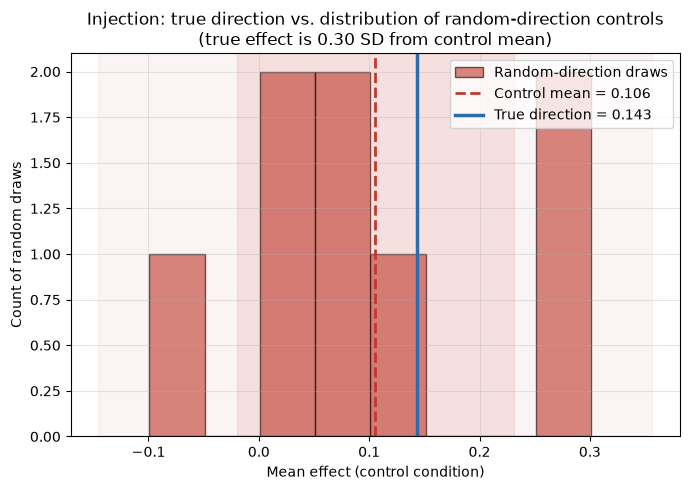

n_random draws: 8
Control distribution: mean=0.106, std=0.126, min=-0.099, max=0.301
True effect: 0.143  ->  z = 0.30


In [35]:
z_injection = plot_control_distribution(control_dist_injection, true_effect_value=inj['true_effect'].mean(), label="Injection")


Do the same for ablation

Draw seed 0
  Analyzing prompt 0
  Analyzing prompt 1
  Analyzing prompt 2
  Analyzing prompt 3
  Analyzing prompt 4
  Analyzing prompt 5
  Analyzing prompt 6
  Analyzing prompt 7
  Analyzing prompt 8
  Analyzing prompt 9
  Analyzing prompt 10
  Analyzing prompt 11
  Analyzing prompt 12
  Analyzing prompt 13
  random draw 0: mean effect = 0.027
Draw seed 1
  Analyzing prompt 0
  Analyzing prompt 1
  Analyzing prompt 2
  Analyzing prompt 3
  Analyzing prompt 4
  Analyzing prompt 5
  Analyzing prompt 6
  Analyzing prompt 7
  Analyzing prompt 8
  Analyzing prompt 9
  Analyzing prompt 10
  Analyzing prompt 11
  Analyzing prompt 12
  Analyzing prompt 13
  random draw 1: mean effect = 0.039
Draw seed 2
  Analyzing prompt 0
  Analyzing prompt 1
  Analyzing prompt 2
  Analyzing prompt 3
  Analyzing prompt 4
  Analyzing prompt 5
  Analyzing prompt 6
  Analyzing prompt 7
  Analyzing prompt 8
  Analyzing prompt 9
  Analyzing prompt 10
  Analyzing prompt 11
  Analyzing prompt 12
  Analyzing prompt

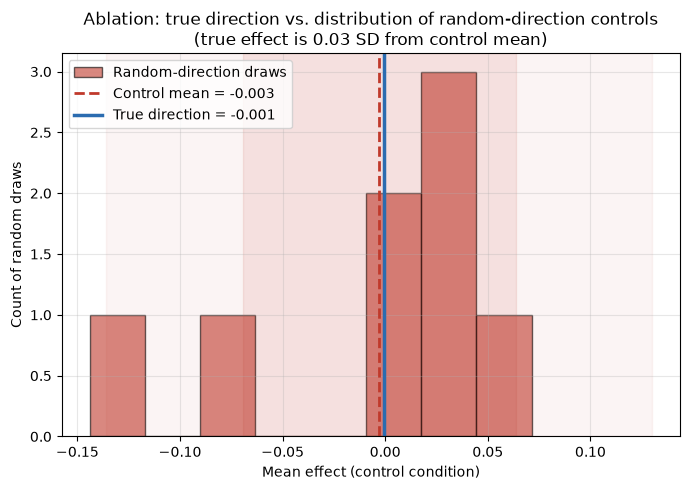

n_random draws: 8
Control distribution: mean=-0.003, std=0.066, min=-0.144, max=0.071
True effect: -0.001  ->  z = 0.03


In [36]:
control_dist_ablation = run_with_multiple_random_controls(model, X_train_by_layer, y_train, eval_data, BEST_LAYER, alpha_pick, mode="ablate", n_random=8)
z_ablation = plot_control_distribution(control_dist_ablation, true_effect_value=abl['true_effect'].mean(), label="Ablation")

Compare previous true-direction effect against this distribution, not a single point

In [37]:
true_effect_value = inj['true_effect'].mean()  # your rerun's true injection effect
z_score = (true_effect_value - control_dist_injection.mean()) / control_dist_injection.std()
print(f"True effect is {z_score:.2f} standard deviations from the random-control distribution for injection")

# Repeat for ablation
true_effect_value_ablation = abl['true_effect'].mean()  # your rerun's true ablation effect
z_score_ablation = (true_effect_value_ablation - control_dist_ablation.mean()) / control_dist_ablation.std()
print(f"True effect is {z_score_ablation:.2f} standard deviations from the random-control distribution for ablation")


True effect is 0.30 standard deviations from the random-control distribution for injection
True effect is 0.03 standard deviations from the random-control distribution for ablation
